In [1]:
# Runtime -> Change runtime type -> T4 GPU
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

2.11.0+cu128
True
Tesla T4


# **PyTorch Core Components**

1. **Tensor (input data, weights, gradients)** (`torch.tensor`, `torch.zeros`, `torch.randn`) — the basic data structure; an n dimensional array that runs on CPU or GPU and can track gradients.

2. **Autograd** (`requires_grad=True`, `.backward()`, `.grad`) — automatic differentiation engine that tracks operations and computes gradients.

3. **nn.Module** (`class Net(nn.Module)`, `forward`) — base class for models and layers; subclass it to define a network.

4. **Layers** (`nn.Linear`, `nn.Conv2d`, `nn.ReLU`, `nn.Dropout`, `nn.Sequential`) — the building blocks of a network.

5. **Loss function** (`nn.CrossEntropyLoss`, `nn.MSELoss`, `nn.BCEWithLogitsLoss`) — measures prediction error.

6. **Optimizer** (`torch.optim.SGD`, `torch.optim.Adam`) — updates weights from gradients.

7. **Dataset and DataLoader** (`torch.utils.data.Dataset`, `DataLoader`) — hold samples and provide batching, shuffling, and iteration.

8. **Training loop** (`optimizer.zero_grad()`, `model(inputs)`, `loss.backward()`, `optimizer.step()`) — the repeated training cycle.

9. **Device** (`torch.device("cuda")`, `.to(device)`) — `cpu` or `cuda`; tensors and models must share a device.

10. **state_dict** (`torch.save`, `model.load_state_dict`, `torch.load`) — learned weights, used for saving and loading.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F # e.g. F.relu(), F.softmax()
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import pandas as pd
import numpy as np

In [3]:
X, y = load_breast_cancer(return_X_y=True)
print(X.shape, y.shape)
feature_names = load_breast_cancer().feature_names

(569, 30) (569,)


In [4]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
sample_df = pd.concat([
    df[df['target'] == 0].head(3),
    df[df['target'] == 1].head(3)
])
sample_df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.71190,0.26540,0.4601,0.11890,0
1,20.570,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.24160,0.18600,0.2750,0.08902,0
2,19.690,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.45040,0.24300,0.3613,0.08758,0
19,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.04781,0.1885,0.05766,...,19.26,99.70,711.2,0.1440,0.1773,0.23900,0.12880,0.2977,0.07259,1
20,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,0.06811,...,20.49,96.09,630.5,0.1312,0.2776,0.18900,0.07283,0.3184,0.08183,1
21,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.02076,0.1815,0.06905,...,15.66,65.13,314.9,0.1324,0.1148,0.08867,0.06227,0.2450,0.07773,1


## **Z-score normalization**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler() # Z-score normalization
X_train = scaler.fit_transform(X_train) # calculates mean and sigma
X_test = scaler.transform(X_test) # uses mean and sigma from X_train

In [6]:
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train).unsqueeze(1).float()
y_test_tensor = torch.from_numpy(y_test).unsqueeze(1).float()

In [7]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [18]:
# NNs are implemented as classes since there are so many things to customize
class BCNet(nn.Module):
  def __init__(self):
    super(BCNet, self).__init__()

    # Funnel structure start wide to capture complex feature combinations & gradually compress that information down toward your final prediction
    self.fc1 = nn.Linear(30, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 32)
    self.fc4 = nn.Linear(32, 1)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.tanh(self.fc3(x))
    x = torch.sigmoid(self.fc4(x))
    return x

model = BCNet()

def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(count_parameters(model))



14337


# **Instantiating our loss, model and optimizer**

In [19]:
loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
#ptimizer = optim.SGD(model.parameters())
#optimizer = optim.RMSprop(model.parameters(), lr=0.001)

In [20]:
epochs = 250
error = []
accuracy_history = []


for epoch in range(epochs):
  model.train()
  running_loss = 0.0

  for x_batch, y_batch in train_loader:
    optimizer.zero_grad()

    preds = model(x_batch) # nn.Module impleneted that this automatically performs the forward pass

    loss = loss_function(preds, y_batch)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() # float

  #print(f"Epoch {epoch+1}: Loss {(running_loss/len(train_loader)):.4f}")
  error.append(running_loss/len(train_loader))

  # EVAL
  model.eval()
  with torch.no_grad():
      y_pred_tensor = model(X_test_tensor)
      y_pred_binary = (y_pred_tensor >= 0.5).float()

  accuracy = accuracy_score(y_test_tensor.numpy(), y_pred_binary.numpy())
  accuracy_history.append(accuracy)
  #print(f"Epoch {epoch+1}: Test Accuracy: {accuracy:.4f}")


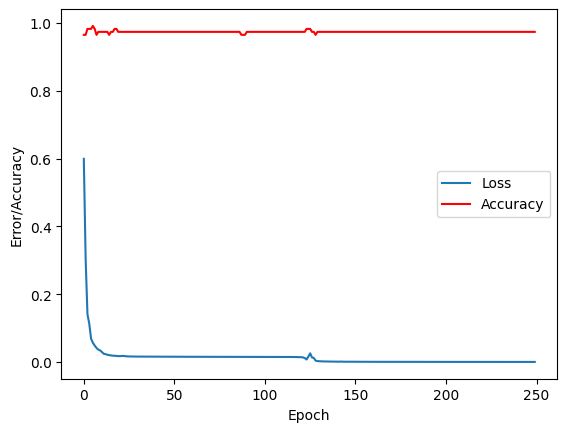

In [21]:
from matplotlib import pyplot as plt
plt.plot(error)
plt.plot(accuracy_history, color='red')
plt.legend(['Loss', 'Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Error/Accuracy')
plt.show()

In [22]:
model.eval()
with torch.no_grad(): # Disable gradient calculation for evaluation
    y_pred_tensor = model(X_test_tensor)
    y_pred_binary = (y_pred_tensor >= 0.5).float() # Convert probabilities to binary (0 or 1)

accuracy = accuracy_score(y_test_tensor.numpy(), y_pred_binary.numpy())
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9737


# **CNNs**

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Scales pixels from [0,1] to [-1,1]
])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 180kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.35MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.9MB/s]


In [25]:
print("\n--- Image Scale ---")
print(f"Total Train Samples: {len(train_dataset)}")
print(f"Single Image Shape:  {train_dataset[0][0].shape}")


--- Image Scale ---
Total Train Samples: 60000
Single Image Shape:  torch.Size([1, 28, 28])


In [27]:
# with nn.Sequential we could implement the architecture without the forward method
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(16 * 14 * 14, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(-1, 16 * 14 * 14) # reshapes data to [batch_size, 3136] => if batch_size = 1 its a vector
        x = self.fc(x)
        return x

model = ConvNet()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(count_parameters(model))

31530


In [28]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [29]:
model.train()
for epoch in range(10): # Just 3 epochs for a quick test
    running_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        preds = model(x_batch)
        loss = loss_function(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f}")

Epoch 1 Loss: 0.4478
Epoch 2 Loss: 0.3189
Epoch 3 Loss: 0.2870
Epoch 4 Loss: 0.2704
Epoch 5 Loss: 0.2519
Epoch 6 Loss: 0.2414
Epoch 7 Loss: 0.2306
Epoch 8 Loss: 0.2213
Epoch 9 Loss: 0.2112
Epoch 10 Loss: 0.2066


# **RNN**

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [31]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
data = df['Passengers'].values.astype(float).reshape(-1, 1)
print(df.shape)
df.tail()

(144, 2)


,Month,Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [32]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_windows(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

X, y = create_windows(scaled_data, window_size=12)
# X shape: (132 samples, 12 months sequence length, 1 feature)
# y shape: (132 samples, 1 target value)

In [33]:
class PassengerRNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 1 input feature (passenger count), 16 internal memory hidden units
        self.rnn = nn.RNN(input_size=1, hidden_size=16, batch_first=True)
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        rnn_out, hidden = self.rnn(x)
        # Grab only the final hidden state after processing all 12 months
        last_hidden = hidden.squeeze(0)
        return self.fc(last_hidden)

model = PassengerRNN()

In [35]:
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

model.train()
for epoch in range(500):
    optimizer.zero_grad()

    preds = model(X)
    loss = loss_function(preds, y)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:03d} | MSE Loss: {loss.item():.6f}")

Epoch 050 | MSE Loss: 0.002500
Epoch 100 | MSE Loss: 0.001856
Epoch 150 | MSE Loss: 0.002778
Epoch 200 | MSE Loss: 0.001731
Epoch 250 | MSE Loss: 0.001505
Epoch 300 | MSE Loss: 0.001296
Epoch 350 | MSE Loss: 0.004526
Epoch 400 | MSE Loss: 0.001587
Epoch 450 | MSE Loss: 0.002326
Epoch 500 | MSE Loss: 0.001286


In [36]:
model.eval()
with torch.no_grad():
    # Grab the absolute last 12-month window from our data
    last_window = scaled_data[-12:].reshape(1, 12, 1)
    last_window_tensor = torch.tensor(last_window, dtype=torch.float32)

    # Predict the next month
    scaled_prediction = model(last_window_tensor).numpy()

    # Reverse the MinMaxScaler to get the actual number of people
    real_prediction = scaler.inverse_transform(scaled_prediction)

    print(f"\nHistorical Last Month Value: {int(data[-1][0])} thousand passengers")
    print(f"RNN Forecasted Next Month:    {int(real_prediction[0][0])} thousand passengers")


Historical Last Month Value: 432 thousand passengers
RNN Forecasted Next Month:    463 thousand passengers


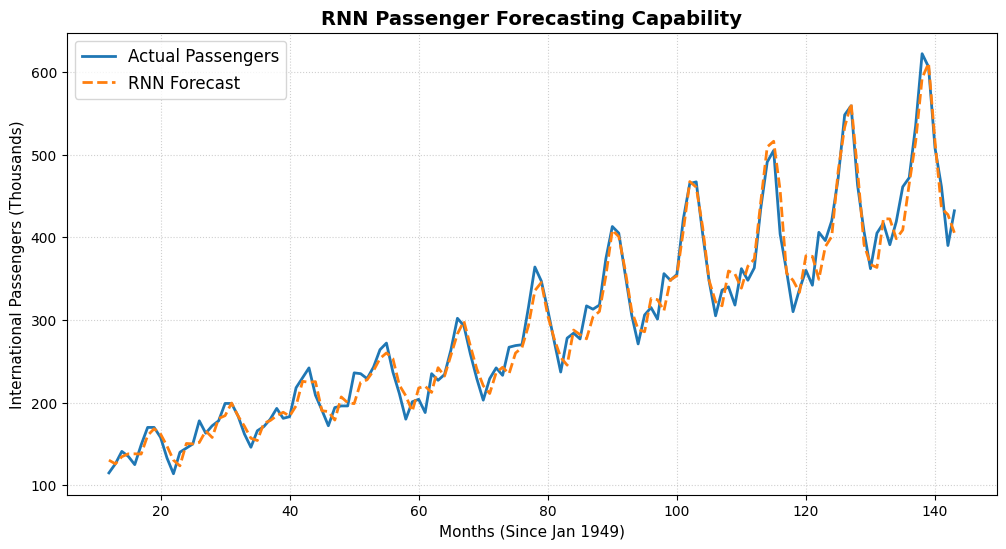

In [37]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    all_preds_scaled = model(X).numpy()

# Reverse the MinMaxScaler back to original passenger counts (in thousands)
all_preds_real = scaler.inverse_transform(all_preds_scaled)
actual_targets_real = scaler.inverse_transform(y.numpy())

# Create historical time-steps for the X-axis (offsetting by the 12-month window)
months = np.arange(12, len(data))

# Generate the Plot
plt.figure(figsize=(12, 6))
plt.plot(months, actual_targets_real, label="Actual Passengers", color="#1f77b4", linewidth=2)
plt.plot(months, all_preds_real, label="RNN Forecast", color="#ff7f0e", linestyle="--", linewidth=2)
plt.title("RNN Passenger Forecasting Capability", fontsize=14, fontweight='bold')
plt.xlabel("Months (Since Jan 1949)", fontsize=11)
plt.ylabel("International Passengers (Thousands)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=12)

plt.show()